In [1]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

train_df= pd.read_csv('train.csv')
test_df= pd.read_csv('test.csv')
submission_df= pd.read_csv('sample_submission.csv')
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nFirst 5 rows:")
print(train_df.head())
print("\nData types:")
print(train_df.dtypes)
print("\nMissing values:")
print(train_df.isnull().sum())

Train shape: (630000, 21)
Test shape: (270000, 20)

First 5 rows:
   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0   0     Loamy     4.92          32.58            1.01   
1   1      Clay     7.08          56.61            0.44   
2   2      Clay     5.69          27.71            0.81   
3   3     Sandy     5.65          13.32            1.33   
4   4      Clay     7.96          59.14            0.38   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                     3.05          15.01     50.61       725.99   
1                     2.00          22.92     67.86       985.66   
2                     2.83          26.97     92.22      2201.70   
3                     0.87          13.32     61.57      1357.33   
4                     0.96          20.22     91.11      1538.20   

   Sunlight_Hours  ...  Crop_Type Crop_Growth_Stage  Season Irrigation_Type  \
0            5.90  ...  Sugarcane            Sowing    Zaid            Drip   
1           

                  id        Soil_pH  Soil_Moisture  Organic_Carbon  \
count  630000.000000  630000.000000  630000.000000   630000.000000   
mean   314999.500000       6.482497      37.304482        0.922858   
std    181865.479132       0.922504      16.377082        0.365808   
min         0.000000       4.800000       8.000000        0.300000   
25%    157499.750000       5.690000      23.340000        0.610000   
50%    314999.500000       6.440000      37.750000        0.910000   
75%    472499.250000       7.270000      51.270000        1.220000   
max    629999.000000       8.200000      64.990000        1.600000   

       Electrical_Conductivity  Temperature_C       Humidity    Rainfall_mm  \
count            630000.000000  630000.000000  630000.000000  630000.000000   
mean                  1.744605      26.998166      61.563180    1462.207566   
std                   0.952321       8.623621      19.708152     612.989738   
min                   0.100000      12.000000      25

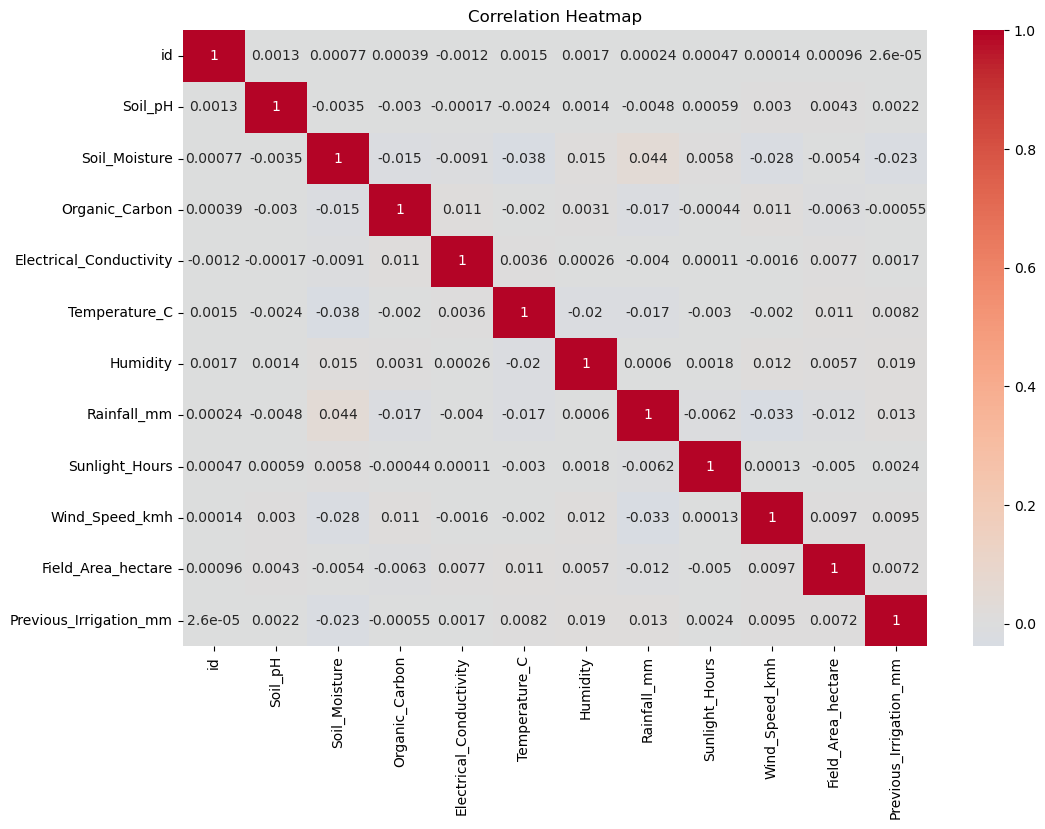

In [ ]:
print(train_df.describe())

if 'target' in train_df.columns:
    print("\nTarget distribution:")
    print(train_df['target'].value_counts())
    
    plt.figure(figsize=(8, 5))
    train_df['target'].value_counts().plot(kind='bar')
    plt.title('Target Variable Distribution')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 8))
    sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap')
    plt.show()

In [ ]:
X = train_df.drop(['id', 'Irrigation_Need'], axis=1)
y = train_df['Irrigation_Need']
X_test = test_df.drop(['id'], axis=1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Test shape: {X_test.shape}")

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
if len(categorical_cols) > 0:
    le_dict = {}
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
        le_dict[col] = le
        print(f"Encoded {col}: {le.classes_}")
if X.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            if col in numerical_cols:
                X[col].fillna(X[col].median(), inplace=True)
                X_test[col].fillna(X_test[col].median(), inplace=True)
            else:
                X[col].fillna(X[col].mode()[0], inplace=True)
                X_test[col].fillna(X_test[col].mode()[0], inplace=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

print("\nPreprocessing completed!")

Features shape: (630000, 19)
Target shape: (630000,)
Test shape: (270000, 19)

Categorical columns (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
Numerical columns (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
Encoded Soil_Type: ['Clay' 'Loamy' 'Sandy' 'Silt']
Encoded Crop_Type: ['Cotton' 'Maize' 'Potato' 'Rice' 'Sugarcane' 'Wheat']
Encoded Crop_Growth_Stage: ['Flowering' 'Harvest' 'Sowing' 'Vegetative']
Encoded Season: ['Kharif' 'Rabi' 'Zaid']
Encoded Irrigation_Type: ['Canal' 'Drip' 'Rainfed' 'Sprinkler']
Encoded Water_Source: ['Groundwater' 'Rainwater' 'Reservoir' 'River']
Encoded Mulching_Used: ['No' 'Yes']
Encoded Region: ['Central' 'East' 'North' 'South' 'West']

Preprocessing completed!


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
except:
    print("XGBoost not available")

try:
    from lightgbm import LGBMClassifier
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
except:
    print("LightGBM not available")
results = {}
predictions = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")
    
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    train_accuracy = accuracy_score(y_train, y_pred_train)
    val_accuracy = accuracy_score(y_val, y_pred_val)
    
    results[name] = {
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy
    }
    predictions[name] = y_pred_val
    
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Overfitting: {train_accuracy - val_accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred_val))
print("MODEL COMPARISON SUMMARY")
print(f"{'Model':<25} {'Train Acc':<15} {'Val Acc':<15} {'Difference':<15}")
for name, scores in results.items():
    diff = scores['train_accuracy'] - scores['val_accuracy']
    print(f"{name:<25} {scores['train_accuracy']:<15.4f} {scores['val_accuracy']:<15.4f} {diff:<15.4f}")
best_model_name = max(results, key=lambda x: results[x]['val_accuracy'])
print(f"Best Model: {best_model_name}")
print(f"Validation Accuracy: {results[best_model_name]['val_accuracy']:.4f}")

Training set size: 504000
Validation set size: 126000

Training Logistic Regression...
Training Accuracy: 0.7489
Validation Accuracy: 0.7488
Overfitting: 0.0001

Classification Report:
              precision    recall  f1-score   support

        High       0.68      0.36      0.47      4202
         Low       0.79      0.84      0.81     73983
      Medium       0.68      0.65      0.66     47815

    accuracy                           0.75    126000
   macro avg       0.72      0.61      0.65    126000
weighted avg       0.75      0.75      0.74    126000


Training Decision Tree...
Training Accuracy: 1.0000
Validation Accuracy: 0.9703
Overfitting: 0.0297

Classification Report:
              precision    recall  f1-score   support

        High       0.88      0.91      0.89      4202
         Low       0.98      0.98      0.98     73983
      Medium       0.96      0.96      0.96     47815

    accuracy                           0.97    126000
   macro avg       0.94      0.95    

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got ['High' 'Low' 'Medium']

In [ ]:

best_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("Training model with good default parameters...")
best_model.fit(X_train, y_train)

# Evaluate
y_pred = best_model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Training model with good default parameters...
Validation Accuracy: 0.9859

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.91      0.94      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.99      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000



In [ ]:
final_model = models[best_model_name]  # or use rf_grid.best_estimator_

print("Training final model on full dataset...")
final_model.fit(X_scaled, y)
test_predictions = final_model.predict(X_test_scaled)

print(f"\nTest predictions distribution:")
unique, counts = np.unique(test_predictions, return_counts=True)
for val, count in zip(unique, counts):
    print(f"Class {val}: {count} ({count/len(test_predictions)*100:.2f}%)")

submission = pd.DataFrame({
    'id': test_df['id'],
    'Irrigation_Need': test_predictions
})

print("\nSubmission file preview:")
print(submission.head(10))
print(f"\nSubmission shape: {submission.shape}")
print(f"Expected shape: {submission_df.shape}")
print(f"\nColumns match: {list(submission.columns) == list(submission_df.columns)}")
submission.to_csv('submission.csv', index=False)

Training final model on full dataset...

Test predictions distribution:
Class High: 8495 (3.15%)
Class Low: 159857 (59.21%)
Class Medium: 101648 (37.65%)

Submission file preview:
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
5  630005          Medium
6  630006             Low
7  630007          Medium
8  630008          Medium
9  630009             Low

Submission shape: (270000, 2)
Expected shape: (270000, 2)

Columns match: True

✅ Submission file created successfully!


ERROR ANALYSIS
Total validation samples: 126000
Correct predictions: 124222 (98.59%)
Misclassified: 1778 (1.41%)

Misclassified samples breakdown:
true    predicted
Medium  Low          965
High    Medium       361
Low     Medium       338
Medium  High         114
Name: count, dtype: int64

Prediction confidence for errors:
Mean confidence on misclassified: 0.8600
Mean confidence on correct: 0.9571

Confusion Matrix:
[[ 3841     0   361]
 [    0 73645   338]
 [  114   965 46736]]


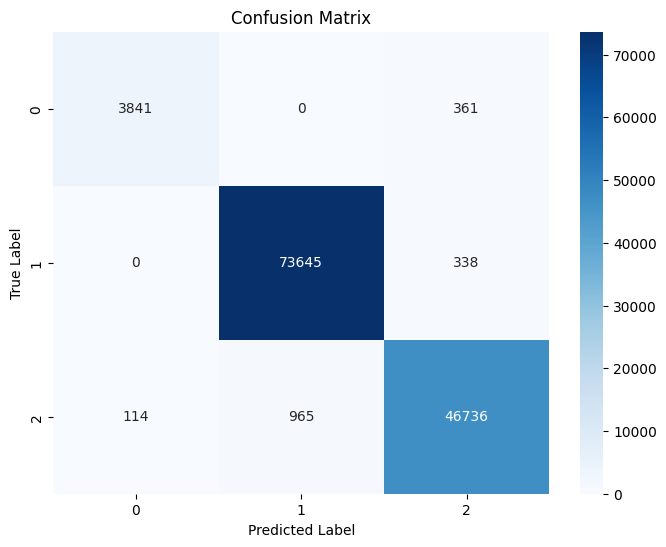


Detailed Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.91      0.94      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.99      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
y_pred_val = best_model.predict(X_val)
y_pred_proba = best_model.predict_proba(X_val)
misclassified_idx = y_val != y_pred_val
correct_idx = y_val == y_pred_val

print(f"Total validation samples: {len(y_val)}")
print(f"Correct predictions: {correct_idx.sum()} ({correct_idx.sum()/len(y_val)*100:.2f}%)")
print(f"Misclassified: {misclassified_idx.sum()} ({misclassified_idx.sum()/len(y_val)*100:.2f}%)")
print("\nMisclassified samples breakdown:")
misclass_df = pd.DataFrame({
    'true': y_val[misclassified_idx],
    'predicted': y_pred_val[misclassified_idx],
    'max_proba': y_pred_proba[misclassified_idx].max(axis=1)
})
print(misclass_df.value_counts(['true', 'predicted']))

print("\nPrediction confidence for errors:")
print(f"Mean confidence on misclassified: {misclass_df['max_proba'].mean():.4f}")
print(f"Mean confidence on correct: {y_pred_proba[correct_idx].max(axis=1).mean():.4f}")
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_pred_val)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_val, y_pred_val))